# SHRED for Multi-Fidelity Mapping in Neutronics
This notebook adopts Shallow Recurrent Decoders to map the output of a point kinetics with 2 groups of delayed precursors to the high-dimensional solution manifold of a 2D diffusion transient problem, following different reactivity insertion laws (step, ramp, etc.).

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import cm

path_snaps = '../../NuSHRED_Datasets/D5/'

transient_types = sorted([d for d in os.listdir(path_snaps) if os.path.isdir(os.path.join(path_snaps, d))])
print(transient_types)

var_names = ['phi1', 'phi2', 'c1', 'c2']  # Fast flux, Thermal flux, Precursor group 1, Precursor group 2
text_var_names = [r'\phi_1', r'\phi_2', r'c_1', r'c_2']

['Ramp', 'Sinusoidal', 'Trapz']


Loading the high-dimensional snapshots

In [2]:
snapshots = dict()
Ns_per_type = dict()
parameters = dict()

for _type_i, _type in enumerate(transient_types):
    print(f"Loading snapshots for transient type: {_type}")

    for field_i, field in enumerate(var_names):

        _data = np.load(os.path.join(path_snaps, _type)+'/snapshots_diffusion_' + field + '.npz', allow_pickle=True)['snapshots']

        if _type_i == 0:
            snapshots[field] = _data
        else:
            snapshots[field] = np.concatenate((snapshots[field], _data), axis=0)

    Ns_per_type[_type] = _data.shape[0]
    parameters[_type] = np.load(os.path.join(path_snaps, _type)+'/parameters_diffusion.npz', allow_pickle=True)['parameters']

print('------------------------------------------------------------')

parameters_concatenated = np.concatenate([parameters[_type] for _type in transient_types], axis=0)

Ns = snapshots[var_names[0]].shape[0]  # Number of parametric samples
Nt = snapshots[var_names[0]].shape[1]  # Number of time steps
Nh = [snapshots[field].shape[2] for field in var_names]  # Number of spatial dofs for each field
print(f"Number of samples: {Ns}, number of time steps: {Nt}, number of spatial dofs: {Nh}")

Loading snapshots for transient type: Ramp
Loading snapshots for transient type: Sinusoidal
Loading snapshots for transient type: Trapz
------------------------------------------------------------
Number of samples: 150, number of time steps: 160, number of spatial dofs: [3770, 3770, 7318, 7318]


Let us scale the snapshots between 0 and 1

In [3]:
min_values = {
    field: np.min(snapshots[field]) for field in var_names
}
max_values = {
    field: np.max(snapshots[field]) for field in var_names
}

for field in var_names:
    snapshots[field] = (snapshots[field] - min_values[field]) / (max_values[field] - min_values[field])

Let us load the PK snapshots

In [4]:
for _type_i, _type in enumerate(transient_types):

    print(f"Loading snapshots for transient type: {_type}")

    if _type_i == 0:
        pk_snaps = np.load(os.path.join(path_snaps, _type)+'/snapshots_pk.npz', allow_pickle=True)['snapshots'][:, 1:]
    else:
        pk_snaps = np.concatenate((pk_snaps, np.load(os.path.join(path_snaps, _type)+'/snapshots_pk.npz', allow_pickle=True)['snapshots'][:, 1:]), axis=0)

Loading snapshots for transient type: Ramp
Loading snapshots for transient type: Sinusoidal
Loading snapshots for transient type: Trapz


Let us define the train, test and validation sets

In [5]:
from sklearn.model_selection import train_test_split

train_val_indices, test_indices = train_test_split(np.arange(Ns), test_size=0.20, random_state=42)
train_indices, val_indices = train_test_split(train_val_indices, test_size=0.10, random_state=42) 

print(f"Train samples: {len(train_indices)}, Validation samples: {len(val_indices)}, Test samples: {len(test_indices)}")
print(f'Train Percentage: {100*len(train_indices)/Ns:.2f}%, Validation Percentage: {100*len(val_indices)/Ns:.2f}%, Test Percentage: {100*len(test_indices)/Ns:.2f}%')

Train samples: 108, Validation samples: 12, Test samples: 30
Train Percentage: 72.00%, Validation Percentage: 8.00%, Test Percentage: 20.00%


Define test labels

In [6]:
test_list = list()
for idx in test_indices:
        if idx < Ns_per_type['Ramp']:
            test_list.append(
                    [idx, 'Ramp', parameters['Ramp'][idx],
                    r'\mu_1', r'\mu_2'])
        elif idx < Ns_per_type['Ramp'] + Ns_per_type['Sinusoidal']:
            adj_idx = idx - Ns_per_type['Ramp']
            test_list.append(
                    [adj_idx, 'Sinusoidal', parameters['Sinusoidal'][adj_idx],
                    r'\mu_1', r'\mu_3'])
        else:
            adj_idx = idx - Ns_per_type['Ramp'] - Ns_per_type['Sinusoidal']
            test_list.append(
                    [adj_idx, 'Trapz', parameters['Trapz'][adj_idx],
                    r'\mu_1', r'\mu_4'])

## Singular Value Decomposition
The diffusion problem solves for the fast and thermal fluxes as well as for 2 groups of precursors, leading to a total of 4 fields. In order to reduce the dimensionality of the output space, the SVD is used to extract the dominant spatial modes for each field.

In [7]:
from sklearn.utils.extmath import randomized_svd

modes = dict()
singular_values = dict()

for field_i, field in enumerate(var_names):
    print(f"Computing SVD for field: {field}")

    # Reshape the snapshots to 2D matrix (space x (params * time))
    X = snapshots[field][train_indices].reshape(-1, Nh[field_i]).T

    # Compute the SVD
    _u, _s, _ = randomized_svd(X, n_components=10, random_state=42)
    
    modes[field] = _u
    singular_values[field] = _s

Computing SVD for field: phi1
Computing SVD for field: phi2
Computing SVD for field: c1
Computing SVD for field: c2


Let us plot the singular values

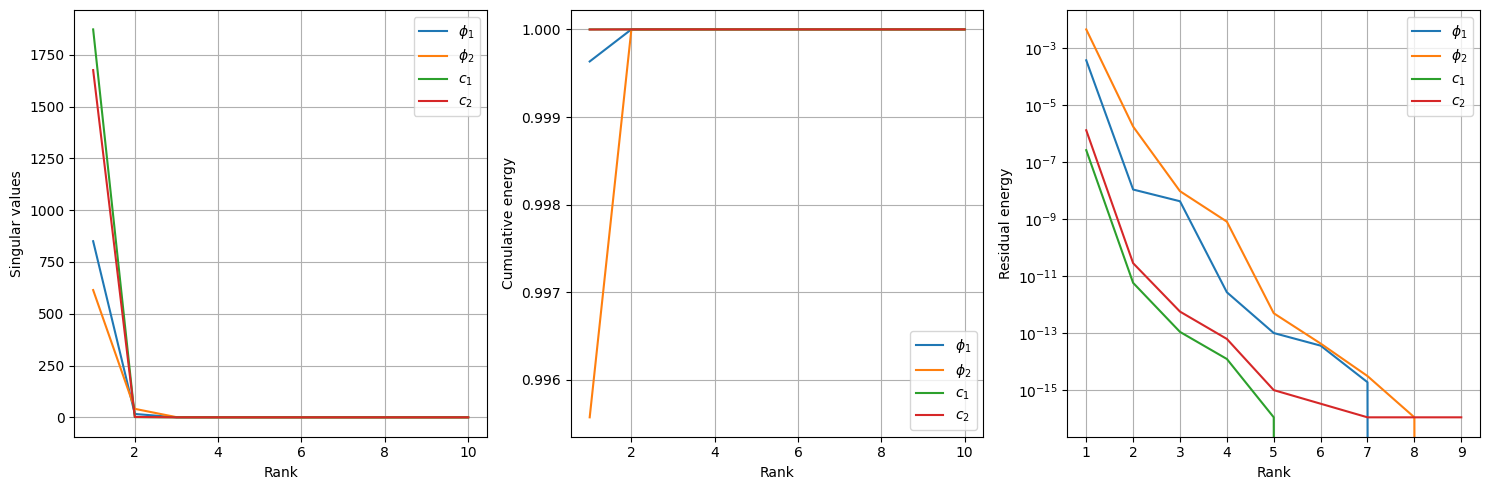

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

Nplot = np.arange(1, 11)

for field_i, field in enumerate(var_names):
    _s = singular_values[field]
    axs[0].plot(Nplot, _s, label='$'+text_var_names[field_i]+'$')
    axs[1].plot(Nplot, np.cumsum(_s**2)/np.sum(_s**2), label='$'+text_var_names[field_i]+'$')
    axs[2].semilogy(Nplot[:-1], 1-np.cumsum(_s**2)[:-1]/np.sum(_s**2), label='$'+text_var_names[field_i]+'$')

for ax in axs:
    ax.grid()
    ax.set_xlabel('Rank')
    ax.legend()

axs[0].set_ylabel('Singular values')
axs[1].set_ylabel('Cumulative energy')
axs[2].set_ylabel('Residual energy')

plt.tight_layout()

Let us make a plot of the spatial modes for each field using the `PlotReactor` class.

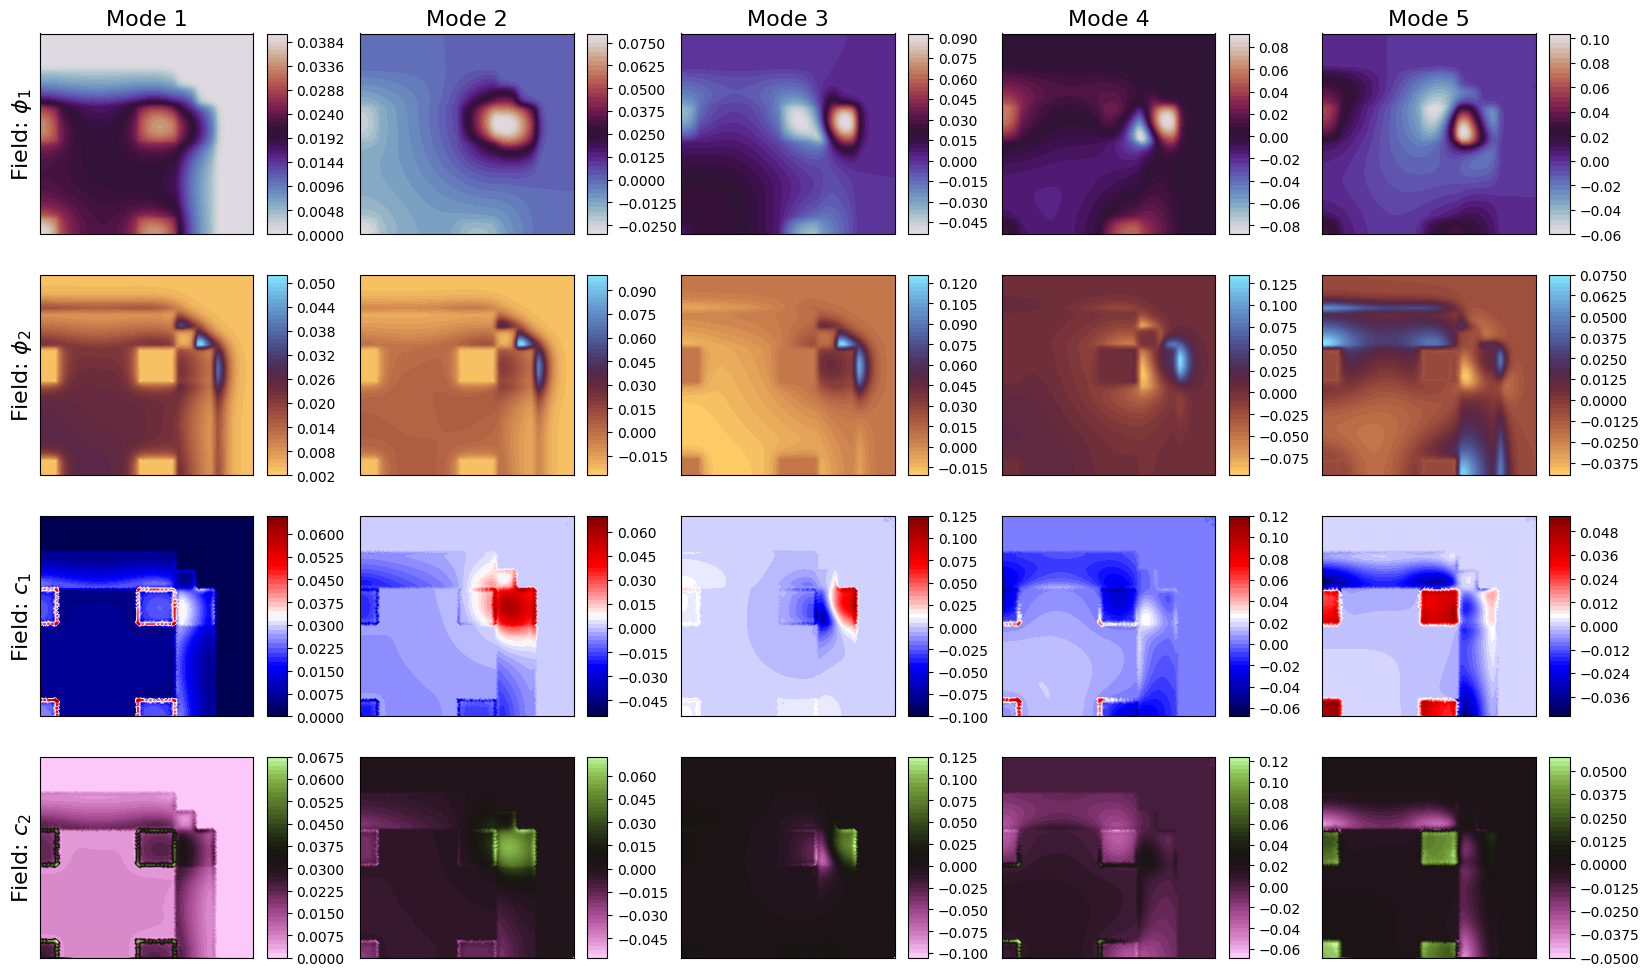

In [9]:
import matplotlib.pyplot as plt
from matplotlib import cm
import pickle

class PlotReactor:
    def __init__(self, mesh_path='../../NuSHRED_Datasets/D5/'):
        
        self.nodes = pickle.load(open(mesh_path + 'nodes.pkl', 'rb')).copy()

    def plot_contour(self, axs, snap, field_i,
                     cmap=cm.viridis, levels = 50, show_ticks=False):
        
        _nodes = self.nodes[field_i]
        
        c = axs.tricontourf(_nodes[:,0], _nodes[:,1], snap, 
                            levels=levels, cmap=cmap)
        if not show_ticks:
            axs.set_xticks([])
            axs.set_yticks([])
        return c

cmaps = [
    cm.twilight,
    cm.managua,
    cm.seismic,
    cm.vanimo
]

plotter = PlotReactor()

n_rows = len(var_names)
ncols = 5

fig, axs = plt.subplots(n_rows, ncols, figsize=(4*ncols, 3*n_rows))

for field_i, field in enumerate(var_names):
    for rr in range(ncols):
        c = plotter.plot_contour(
            axs[field_i, rr], modes[field][:, rr], field_i=field_i, cmap=cmaps[field_i]
        )
        fig.colorbar(c, ax=axs[field_i, rr], aspect=10)

        if field_i == 0:
            axs[field_i, rr].set_title(f'Mode {rr+1}', fontsize=16)
    axs[field_i, 0].set_ylabel(f'Field: ${text_var_names[field_i]}$', fontsize=16)

Let us compute the reduced coefficients for each field

In [10]:
train_reduced_coeffs = dict()
valid_reduced_coeffs = dict()
test_reduced_coeffs  = dict()

Nmodes = [4]*len(var_names)  # Number of modes to retain for each field

for field_i, field in enumerate(var_names):

    _snaps = snapshots[field].reshape(-1, Nh[field_i]).T # shape space x (params*time)
    _red_coeff = (modes[field].T[:Nmodes[field_i]] @ _snaps).T.reshape(Ns, Nt, Nmodes[field_i])

    train_reduced_coeffs[field] = _red_coeff[train_indices]
    valid_reduced_coeffs[field] = _red_coeff[val_indices]
    test_reduced_coeffs[field]  = _red_coeff[test_indices]

    if field_i == 0:
        print(f"Train coefficients shape: {train_reduced_coeffs[field].shape}")
        print(f"Valid coefficients shape: {valid_reduced_coeffs[field].shape}")
        print(f"Test  coefficients shape: {test_reduced_coeffs[field].shape}")


Train coefficients shape: (108, 160, 4)
Valid coefficients shape: (12, 160, 4)
Test  coefficients shape: (30, 160, 4)


## Data Preparation for SHRED
At first let us concatenate the reduced coefficients of all fields.

In [11]:
train_vpod = np.concatenate([train_reduced_coeffs[field] for field in var_names], axis=-1)
valid_vpod = np.concatenate([valid_reduced_coeffs[field] for field in var_names], axis=-1)
test_vpod  = np.concatenate([test_reduced_coeffs[field]  for field in var_names], axis=-1)

Let us define the scaler for the output of the SHRED model

In [12]:
from sklearn.preprocessing import MinMaxScaler

vpod_scaler = MinMaxScaler()
vpod_scaler.fit(train_vpod.reshape(-1, train_vpod.shape[-1]))

train_rescaled_vpod = vpod_scaler.transform(train_vpod.reshape(-1, sum(Nmodes))).reshape(train_vpod.shape)
valid_rescaled_vpod = vpod_scaler.transform(valid_vpod.reshape(-1, sum(Nmodes))).reshape(valid_vpod.shape)
test_rescaled_vpod  = vpod_scaler.transform(test_vpod.reshape(-1, sum(Nmodes))).reshape(test_vpod.shape)

Let us define the scaler for the input data (PK solution)

In [13]:
input_scaler = MinMaxScaler()
input_scaler.fit(pk_snaps[train_indices].reshape(-1, pk_snaps.shape[-1]))

train_rescaled_pk = input_scaler.transform(pk_snaps[train_indices].reshape(-1, pk_snaps.shape[-1])).reshape(pk_snaps[train_indices].shape)
valid_rescaled_pk = input_scaler.transform(pk_snaps[val_indices].reshape(-1, pk_snaps.shape[-1])).reshape(pk_snaps[val_indices].shape)
test_rescaled_pk  = input_scaler.transform(pk_snaps[test_indices].reshape(-1, pk_snaps.shape[-1])).reshape(pk_snaps[test_indices].shape)

### Padding
In this section, we will apply the pre-padding and create the input-output pairs for training the SHRED model.

In [14]:
import sys
sys.path.append('/Users/sriva/Github/PublicRepo/NuSHRED')

from shred.processdata import Padding, TimeSeriesDataset
import torch

# GPU
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
# device = 'cpu'

lags = 30

# Input Data
train_data_in = Padding(torch.from_numpy(train_rescaled_pk), lags).to(device)
valid_data_in = Padding(torch.from_numpy(valid_rescaled_pk), lags).to(device)
test_data_in  = Padding(torch.from_numpy(test_rescaled_pk), lags).to(device)

# Output Data
train_data_out = Padding(torch.from_numpy(train_rescaled_vpod), 1).squeeze(1).to(device)
valid_data_out = Padding(torch.from_numpy(valid_rescaled_vpod), 1).squeeze(1).to(device)
test_data_out  = Padding(torch.from_numpy(test_rescaled_vpod), 1).squeeze(1).to(device)

# Create Dataset for SHRED training
train_dataset = TimeSeriesDataset(train_data_in, train_data_out)
valid_dataset = TimeSeriesDataset(valid_data_in, valid_data_out)
test_dataset  = TimeSeriesDataset(test_data_in,  test_data_out)

## SHRED Training and Testing
Let us train the SHRED model with the input-output pairs defined above.

In [15]:
from shred.models import SHRED, fit
import os

path_results = './Results/'
os.makedirs(path_results, exist_ok=True)

train_net = True

from time import time

shred = SHRED(train_rescaled_pk.shape[-1], sum(Nmodes),
              hidden_size = 64, hidden_layers = 2, decoder_sizes = [350, 400], dropout = 0.1).to(device)

if train_net:
    start_time = time()
    fitting_errs = fit(shred, train_dataset, valid_dataset, 
                       batch_size = 64, epochs = 400, lr = 1e-3, verbose = True, patience = 30)
    end_time = time() - start_time
    
    shred.freeze()

    np.save(os.path.join(path_results, 'training_time.npy'), np.array([end_time]))
    torch.save(shred.state_dict(), os.path.join(path_results, 'model.shred'))

else:
    shred.load_state_dict(torch.load(os.path.join(path_results, 'model.shred'), map_location=device))
    shred.freeze()

Training done: Training loss = 1.50% 	 Validation loss = 1.95%      


Let us chek the test errors on the POD coefficients

In [16]:
from shred.processdata import num2p, mre

Ytest_POD_hat = shred(test_data_in)

# The test data are independent on the configurations of the sensors
print("Mean relative SHRED prediction error on POD coeffs: %s." % num2p(mre(test_data_out, Ytest_POD_hat)))

Mean relative SHRED prediction error on POD coeffs: 1.94%.


Let us reshape the output of the SHRED models and the associated test data to simplify the access to the variables.

In fact, the output of the SHRED models is a 2D array with dimensions $N_p^{test}\cdot N_t \times (R+N_{params})$, given $N_p$ the number of elements in the parameter test set, $N_t$ the number of time steps, $R$ the number of total rank of the latent space and $N_{params}$ the number of parameters (only 1, since $\tau$ only has been considered).

In [17]:
reshaped_test_out = test_data_out.cpu().detach().numpy().reshape(test_rescaled_vpod.shape)
reshaped_POD_test_out = Ytest_POD_hat.cpu().detach().numpy().reshape(test_rescaled_vpod.shape)

Let us plot the errors for each POD coefficient

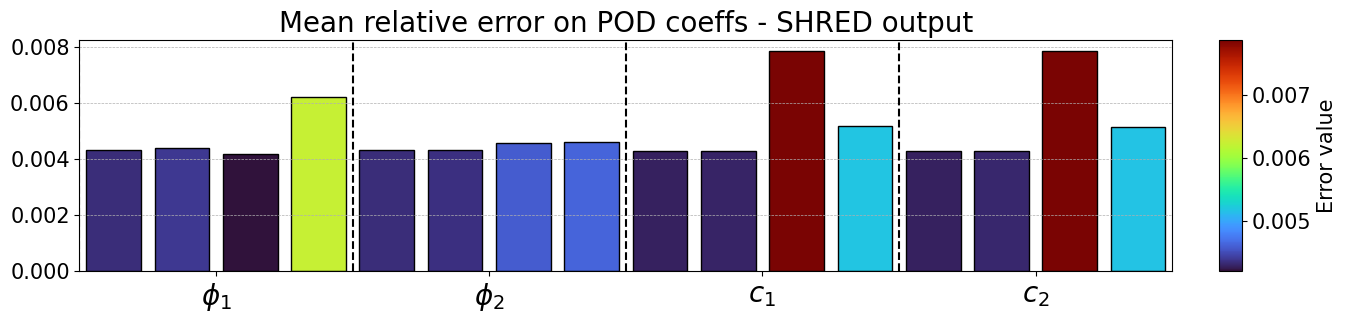

In [18]:
from matplotlib.colors import Normalize

# errors_pod_coeffs already computed
errors_pod_coeffs = [np.mean(np.abs(reshaped_test_out[:, :, pp] - reshaped_POD_test_out[:, :, pp]), axis=(0,1)) 
                     for pp in range(reshaped_test_out.shape[2])]

fig, axs = plt.subplots(1, 1, figsize=(15, 3))

# Normalize error values to [0,1] for colormap mapping
norm = Normalize(vmin=min(errors_pod_coeffs), vmax=max(errors_pod_coeffs))
cmap = cm.turbo
colors = cmap(norm(errors_pod_coeffs))

# Plot bars with colors
bars = axs.bar(np.arange(sum(Nmodes)), errors_pod_coeffs, color=colors, edgecolor='k')

# Vertical lines for Nmodes grouping
for pp in range(len(Nmodes)):
    axs.axvline(x=np.cumsum(Nmodes)[pp]-Nmodes[0]-0.5, color='k', linestyle='--')

axs.set_title('Mean relative error on POD coeffs - SHRED output', fontsize=20)

axs.tick_params(axis='both', which='major', labelsize=15)

# Add x-ticks for modes grouping
xticks = []
xtick_labels = []
for pp in range(len(Nmodes)):
    xticks.append(np.cumsum(Nmodes)[pp]-Nmodes[0]/2-0.5)
    xtick_labels.append(f'${text_var_names[pp]}$')
axs.set_xticks(xticks)
axs.set_xticklabels(xtick_labels, rotation=0, fontsize=20)

axs.grid(which='both', axis='y', linestyle='--', linewidth=0.5)
axs.set_xlim(-0.5, sum(Nmodes)-0.5)

# Add colorbar for reference
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs, fraction=0.02, pad=0.04, aspect=10)
cbar.ax.tick_params(labelsize=15)
cbar.ax.set_ylabel('Error value', fontsize=15)
fig.savefig(path_results+'SHRED_errors_pod_coeffs.pdf', format='pdf', dpi=250, bbox_inches='tight')

Let us plot all the POD coefficients for the test set

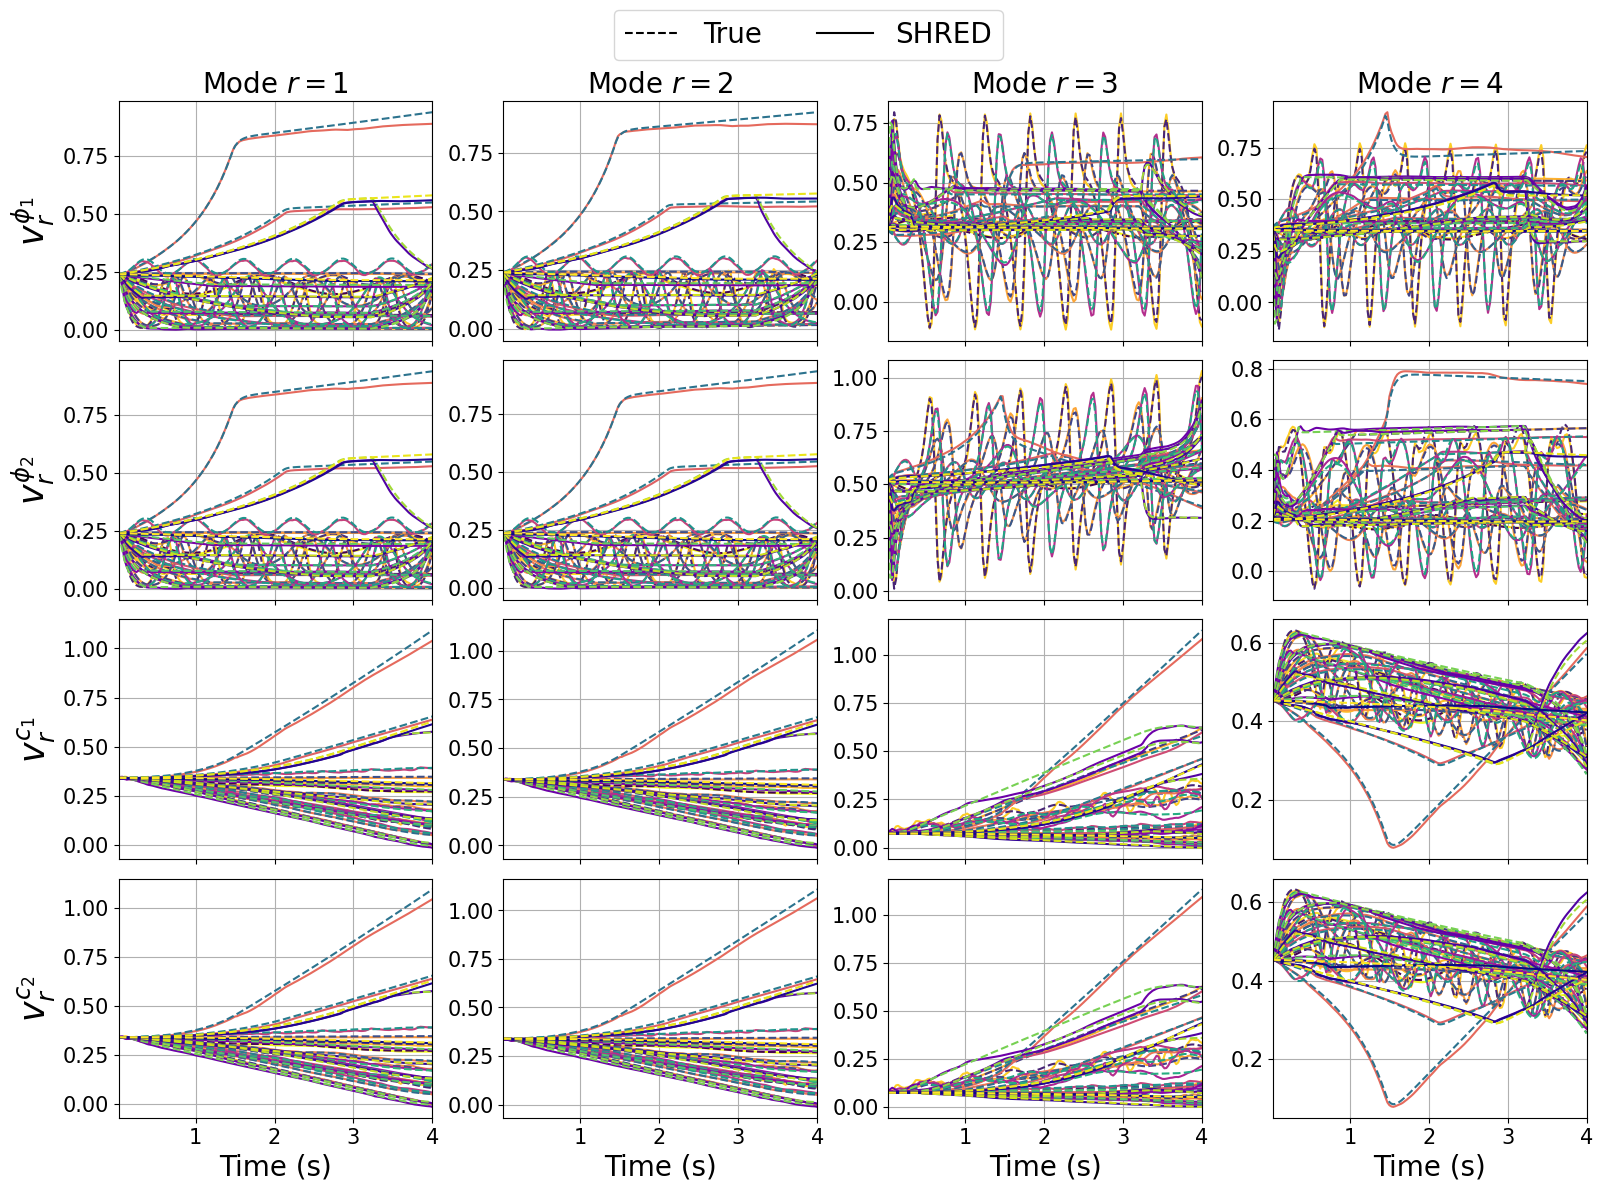

In [19]:
modes_to_plot = 4  # Number of modes to plot for each field

dt = 5e-3 * 5
times = np.arange(dt, (Nt)*dt+1e-12, dt)

nrows = len(var_names)
ncols = modes_to_plot

colors_true = cm.viridis(np.linspace(0., 1, reshaped_test_out.shape[0]))
colors_pred = cm.plasma_r(np.linspace(0., 1, reshaped_test_out.shape[0]))

fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True)

for field_i, field in enumerate(var_names):
    idx_to_plot = np.arange(sum(Nmodes[:field_i]), modes_to_plot + sum(Nmodes[:field_i]), 1, dtype=int)
    
    for rr, idx in enumerate(idx_to_plot):
        for param_i in range(reshaped_test_out.shape[0]):
            axs[field_i, rr].plot(times, reshaped_POD_test_out[param_i, :, idx].T, '-', label='SHRED', color=colors_pred[param_i])
            axs[field_i, rr].plot(times, reshaped_test_out[param_i, :, idx].T, '--', label='True', color=colors_true[param_i])
        
        if field_i == 0:
            axs[field_i, rr].set_title(f'Mode $r={rr+1}$', fontsize=20)
        if field_i == nrows - 1:
            axs[field_i,rr].set_xlabel('Time (s)', fontsize=20)

    axs[field_i, 0].set_ylabel(r'$v_r^{'+text_var_names[field_i]+'}$', fontsize=25)

for ax in axs.flat:
    ax.grid()
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.set_xlim(times[0], times[-1])

# Create dummy handles just for the legend
dummy_true, = axs[0, 0].plot([], [], '--', color='black', label='True')
dummy_shred, = axs[0, 0].plot([], [], '-', color='black', label='SHRED')

fig.legend([dummy_true, dummy_shred], ['True', 'SHRED'], loc='upper center', fontsize=20, ncol=2, bbox_to_anchor=(0.5, 1.0))
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(path_results+'SHRED_pod_time_evolution.pdf', format='pdf', dpi=250, bbox_inches='tight')

### High-dimensional fields
In this last part, errors and plots are generated for the high-dimensional fields, obtained by multiplying the POD modes by the predicted POD coefficients.

In [20]:
start = time()
Ytest_POD_hat = shred(test_data_in)
reshaped_POD_test_out = Ytest_POD_hat.cpu().detach().numpy().reshape(test_rescaled_vpod.shape)
test_shred_out = vpod_scaler.inverse_transform(reshaped_POD_test_out.reshape(-1, sum(Nmodes))).reshape(reshaped_POD_test_out.shape)
test_time = {
    'SHRED': [(time() - start) / reshaped_POD_test_out.shape[0]] * reshaped_POD_test_out.shape[0]
}

Let us calculate the errors and the residual field for each field

In [21]:
errors = dict()
std_errors = dict()
histograms = dict()
average_residuals = dict()
average_value = dict()

test_time['Decoding'] = np.zeros((len(var_names), reshaped_POD_test_out.shape[0]))

for field_i, field in enumerate(var_names):

    _modes = modes[field][:, :Nmodes[field_i]]

    _average_residual = np.zeros((_modes.shape[0],))
    _error = list()
    _std_error = list()

    for param_i in range(test_shred_out.shape[0]):
        
        _test_snap  = snapshots[field][test_indices][param_i].T  # shape space x time


        idx_out_shred = np.arange(sum(Nmodes[:field_i]), Nmodes[field_i] + sum(Nmodes[:field_i]), 1, dtype=int)

        start_time = time()
        _recon_snap = (_modes @ test_shred_out[param_i, :, idx_out_shred]) # shape space x time
        test_time['Decoding'][field_i, param_i] += time() - start_time

        # Define the residual field
        _average_residual += (np.abs(_test_snap - _recon_snap) / np.abs(_test_snap+1e-12) ).mean(axis=1)
        # _average_residual += (np.abs(_test_snap - _recon_snap)).mean(axis=1)
        _error.append(
            np.mean(
                np.linalg.norm(_test_snap - _recon_snap, axis=0) / np.linalg.norm(_test_snap, axis=0)
                    )
        )
        _std_error.append(
            np.std(
                np.linalg.norm(_test_snap - _recon_snap, axis=0) / np.linalg.norm(_test_snap, axis=0)
                    )
        )
    
    # Store the results
    errors[field] = np.mean(_error)
    std_errors[field] = np.mean(_std_error)
    average_residuals[field] = _average_residual / test_shred_out.shape[0]
    histograms[field] = np.histogram(average_residuals[field], bins=25, density=False)
    average_value[field] = np.mean(np.abs(snapshots[field][test_indices]))

np.save(os.path.join(path_results, 'test_time.npy'), test_time)

Let us plot the histograms of the residual fields

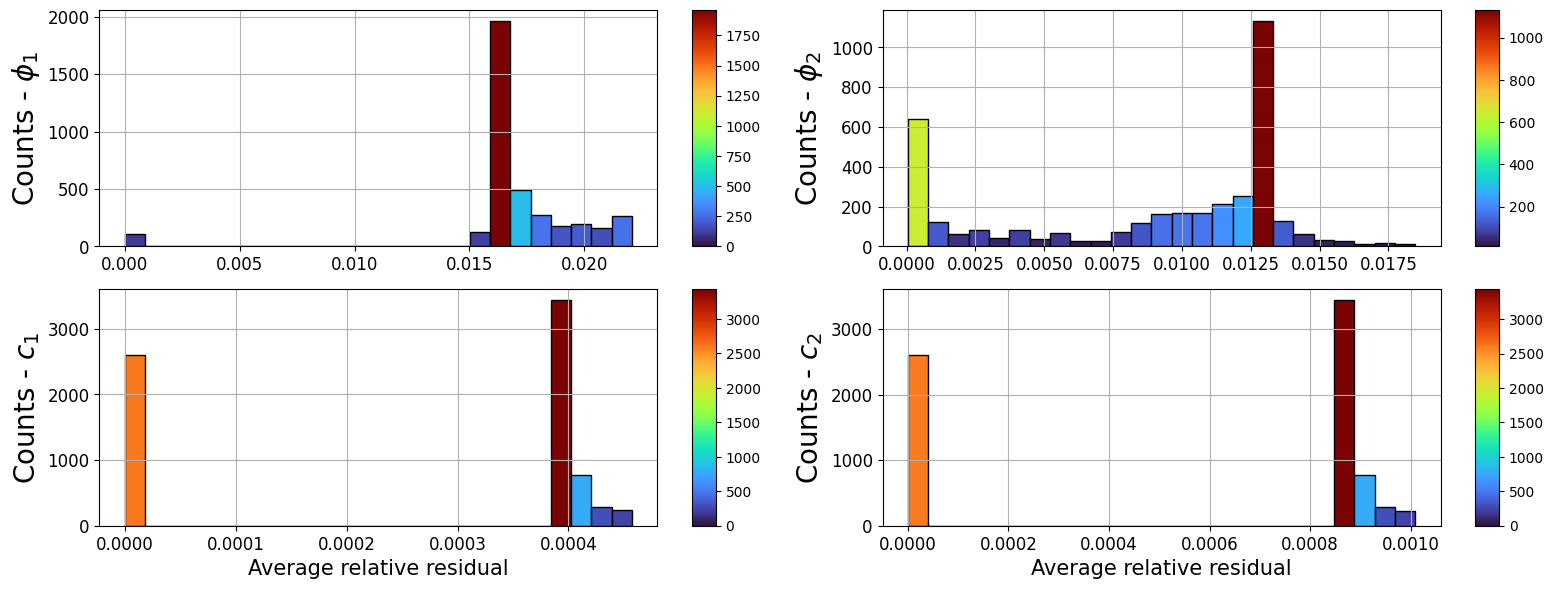

In [22]:
import matplotlib.colors as mcolors

def plot_histograms(ax, _histograms, _field_i, aspect=10):
    _field = var_names[_field_i]
    bin_edges = _histograms[_field][1]
    counts = _histograms[_field][0]

    # Normalize counts for colormap scaling
    norm = mcolors.Normalize(vmin=counts.min(), vmax=counts.max())
    cmap = cm.turbo

    # Compute bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    widths = np.diff(bin_edges)

    # Map each count to a color
    colors = cmap(norm(counts))

    # Draw bar plot with colormapped faces
    ax.bar(bin_centers, counts, width=widths,
                     edgecolor='black', align='center', color=colors)

    # Add a colorbar to each subplot
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, orientation="vertical", aspect=aspect)

nrows = 2
ncols = 2

fig, axs = plt.subplots(nrows, ncols, figsize=(8*ncols, 3*nrows))
axs = axs.flatten()

for field_i, field in enumerate(var_names):
    plot_histograms(axs[field_i], histograms, field_i, aspect=10)
    # axs[field_i].axvline(x=average_value[field], color='k', linestyle='--', label='Average field value')
    if field_i >= ncols:
        axs[field_i].set_xlabel('Average relative residual', fontsize=15)
    axs[field_i].set_ylabel(f'Counts - ${text_var_names[field_i]}$', fontsize=20)
    axs[field_i].tick_params(axis='both', which='major', labelsize=12)
    axs[field_i].grid()
plt.tight_layout()

Let us plot the errors for each field

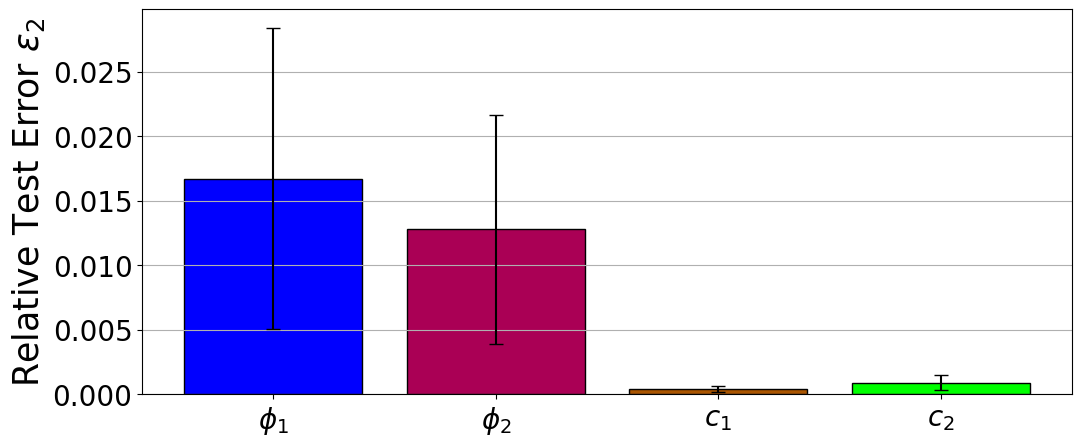

In [24]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize=(12,5))

colors = cm.brg(np.linspace(0,1, len(var_names)))
axs.bar(np.arange(1, len(var_names)+1, 1), [err for err in errors.values()], capsize=5,
        yerr=[std for std in std_errors.values()],
        color = colors,
        edgecolor='black')

axs.set_xticks(np.arange(1,len(var_names)+1,1), ['$'+tex_+'$' for tex_ in text_var_names])
# axs.set_yticks(np.arange(0,0.1,0.01))

axs.tick_params(axis='both', labelsize=20)
axs.set_ylabel(r'Relative Test Error $\varepsilon_{2}$', fontsize=25)
axs.grid(axis='y', linestyle='-')
axs.grid(axis='y', which='minor', linestyle='--')

fig.savefig(path_results+'fom_relativerrror_bars.pdf', format='pdf', dpi=250, bbox_inches='tight')

Let us make a contour plot of the predicted fields for a specific test case

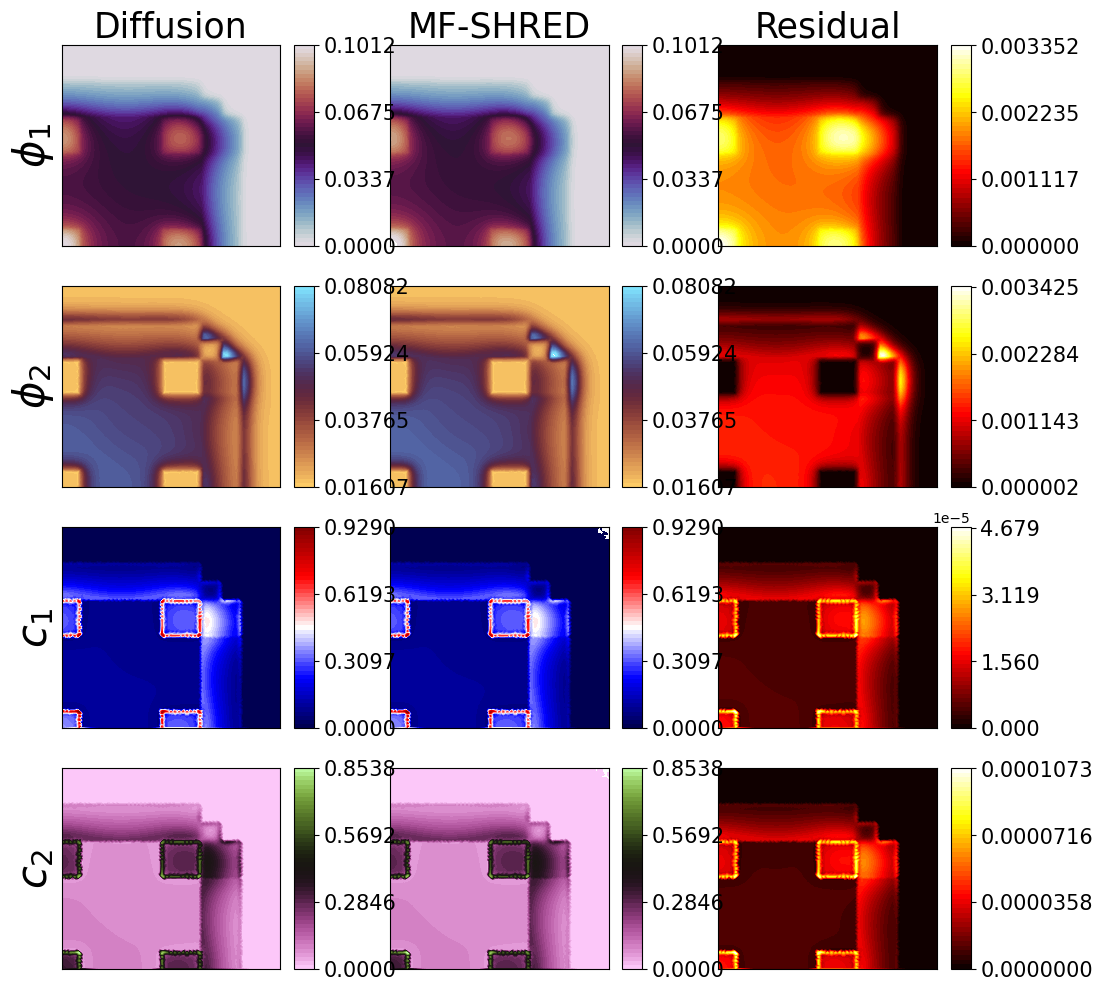

In [25]:
np.random.seed(42)
param_i_to_plot = np.random.choice(test_shred_out.shape[0], 1)[0]

levels = [
    np.linspace(np.min(snapshots[field][test_indices][param_i_to_plot]), np.max(snapshots[field][test_indices][param_i_to_plot]), 50)
    for field in var_names
]

nrows = len(var_names)
ncols = 3

tt = 50  # Time step to plot

fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))

for field_i, field in enumerate(var_names):

    _modes = modes[field][:, :Nmodes[field_i]]

    _test_snap  = snapshots[field][test_indices][param_i_to_plot, tt]

    levels = [
        np.linspace(np.min(_test_snap), np.max(_test_snap), 50)
        for field in var_names
    ]

    idx_out_shred = np.arange(sum(Nmodes[:field_i]), Nmodes[field_i] + sum(Nmodes[:field_i]), 1, dtype=int)
    _recon_snap = (_modes @ test_shred_out[param_i_to_plot, tt, idx_out_shred])

    _residual_snap = np.abs(_test_snap - _recon_snap)

    c0 = plotter.plot_contour(axs[field_i, 0], _test_snap, field_i=field_i, cmap=cmaps[field_i], levels=levels[field_i])
    cbar = fig.colorbar(c0, ax=axs[field_i, 0], aspect=10)
    cbar.ax.set_yticks(np.linspace(levels[field_i][0], levels[field_i][-1], num=4))
    if field_i == 0:
        axs[field_i, 0].set_title('Diffusion', fontsize=25)
    cbar.ax.tick_params(labelsize=15)

    c1 = plotter.plot_contour(axs[field_i, 1], _recon_snap, field_i=field_i, cmap=cmaps[field_i], levels=levels[field_i])
    cbar = fig.colorbar(c1, ax=axs[field_i, 1], aspect=10)
    cbar.ax.set_yticks(np.linspace(levels[field_i][0], levels[field_i][-1], num=4))
    if field_i == 0:
        axs[field_i, 1].set_title('MF-SHRED', fontsize=25)
    cbar.ax.tick_params(labelsize=15)

    c2 = plotter.plot_contour(axs[field_i, 2], _residual_snap, field_i=field_i, cmap=cm.hot)
    # c2 = plotter.plot_contour(axs[field_i, 2], _residual_snap, field_i=field_i, cmap=cmaps[field_i], levels=levels[field_i])
    cbar = fig.colorbar(c2, ax=axs[field_i, 2], aspect=10)
    cbar.ax.set_yticks(np.linspace(np.min(_residual_snap), np.max(_residual_snap), num=4))
    if field_i == 0:
        axs[field_i, 2].set_title('Residual', fontsize=25)
    cbar.ax.tick_params(labelsize=15)

    axs[field_i, 0].set_ylabel(f'${text_var_names[field_i]}$', fontsize=30)

fig.savefig(path_results+f'SHRED_contour_comparison_param{param_i_to_plot}_time{tt}.png', format='png', dpi=250, bbox_inches='tight')

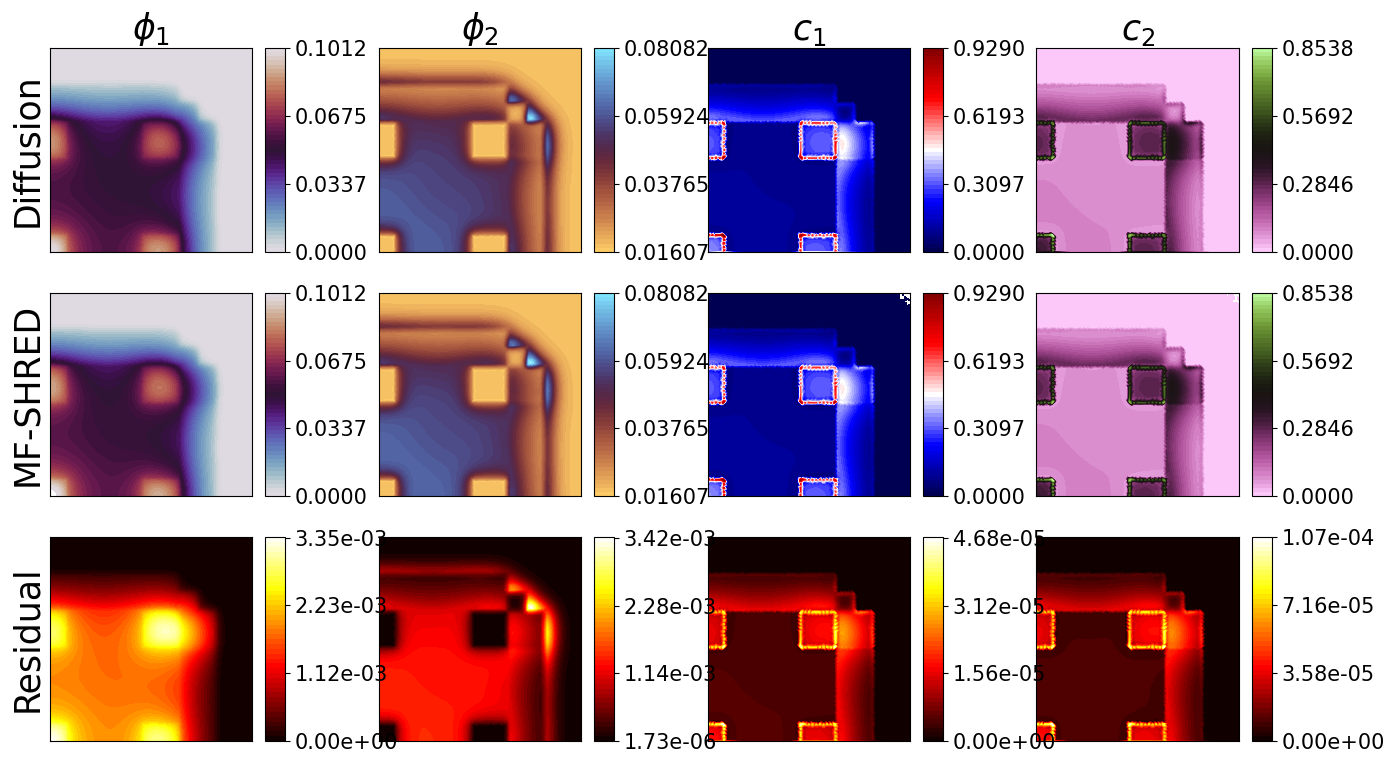

In [26]:
np.random.seed(8)
param_i_to_plot = 6 # np.random.choice(test_shred_out.shape[0], 1)[0]

levels = [
    np.linspace(np.min(snapshots[field][test_indices][param_i_to_plot]),
                np.max(snapshots[field][test_indices][param_i_to_plot]), 50)
    for field in var_names
]

nrows = 3  # Diffusion, MF-SHRED, Residual
ncols = len(var_names)

tt = 50  # Time step to plot

fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))

for field_i, field in enumerate(var_names):

    _modes = modes[field][:, :Nmodes[field_i]]
    _test_snap = snapshots[field][test_indices][param_i_to_plot, tt]

    levels = [
        np.linspace(np.min(_test_snap), np.max(_test_snap), 50)
        for field in var_names
    ]

    idx_out_shred = np.arange(sum(Nmodes[:field_i]), Nmodes[field_i] + sum(Nmodes[:field_i]), 1, dtype=int)
    _recon_snap = (_modes @ test_shred_out[param_i_to_plot, tt, idx_out_shred])
    _residual_snap = np.abs(_test_snap - _recon_snap)

    # --- Row 0: Diffusion (Ground Truth)
    c0 = plotter.plot_contour(axs[0, field_i], _test_snap, field_i=field_i, cmap=cmaps[field_i], levels=levels[field_i])
    cbar = fig.colorbar(c0, ax=axs[0, field_i], aspect=10)
    cbar.ax.set_yticks(np.linspace(levels[field_i][0], levels[field_i][-1], num=4))
    axs[0, field_i].set_title(f'${text_var_names[field_i]}$', fontsize=25)
    cbar.ax.tick_params(labelsize=15)

    # --- Row 1: MF-SHRED Reconstruction
    c1 = plotter.plot_contour(axs[1, field_i], _recon_snap, field_i=field_i, cmap=cmaps[field_i], levels=levels[field_i])
    cbar = fig.colorbar(c1, ax=axs[1, field_i], aspect=10)
    cbar.ax.set_yticks(np.linspace(levels[field_i][0], levels[field_i][-1], num=4))
    cbar.ax.tick_params(labelsize=15)

    # --- Row 2: Residual
    c2 = plotter.plot_contour(axs[2, field_i], _residual_snap, field_i=field_i, cmap=cm.hot)
    
    from matplotlib.ticker import FormatStrFormatter

    cbar = fig.colorbar(c2, ax=axs[2, field_i], aspect=10)
    cbar.ax.set_yticks(np.linspace(np.min(_residual_snap), np.max(_residual_snap), num=4))
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2e'))
    cbar.ax.tick_params(labelsize=15)

# Label rows instead of columns
axs[0, 0].set_ylabel('Diffusion', fontsize=25)
axs[1, 0].set_ylabel('MF-SHRED', fontsize=25)
axs[2, 0].set_ylabel('Residual', fontsize=25)

fig.subplots_adjust(wspace=0.3)

fig.savefig(path_results + f'SHRED_contour_comparison_param{param_i_to_plot}_time{tt}_transposed.png',
            format='png', dpi=250, bbox_inches='tight')


Let us make a plot of the average quantities over the test set

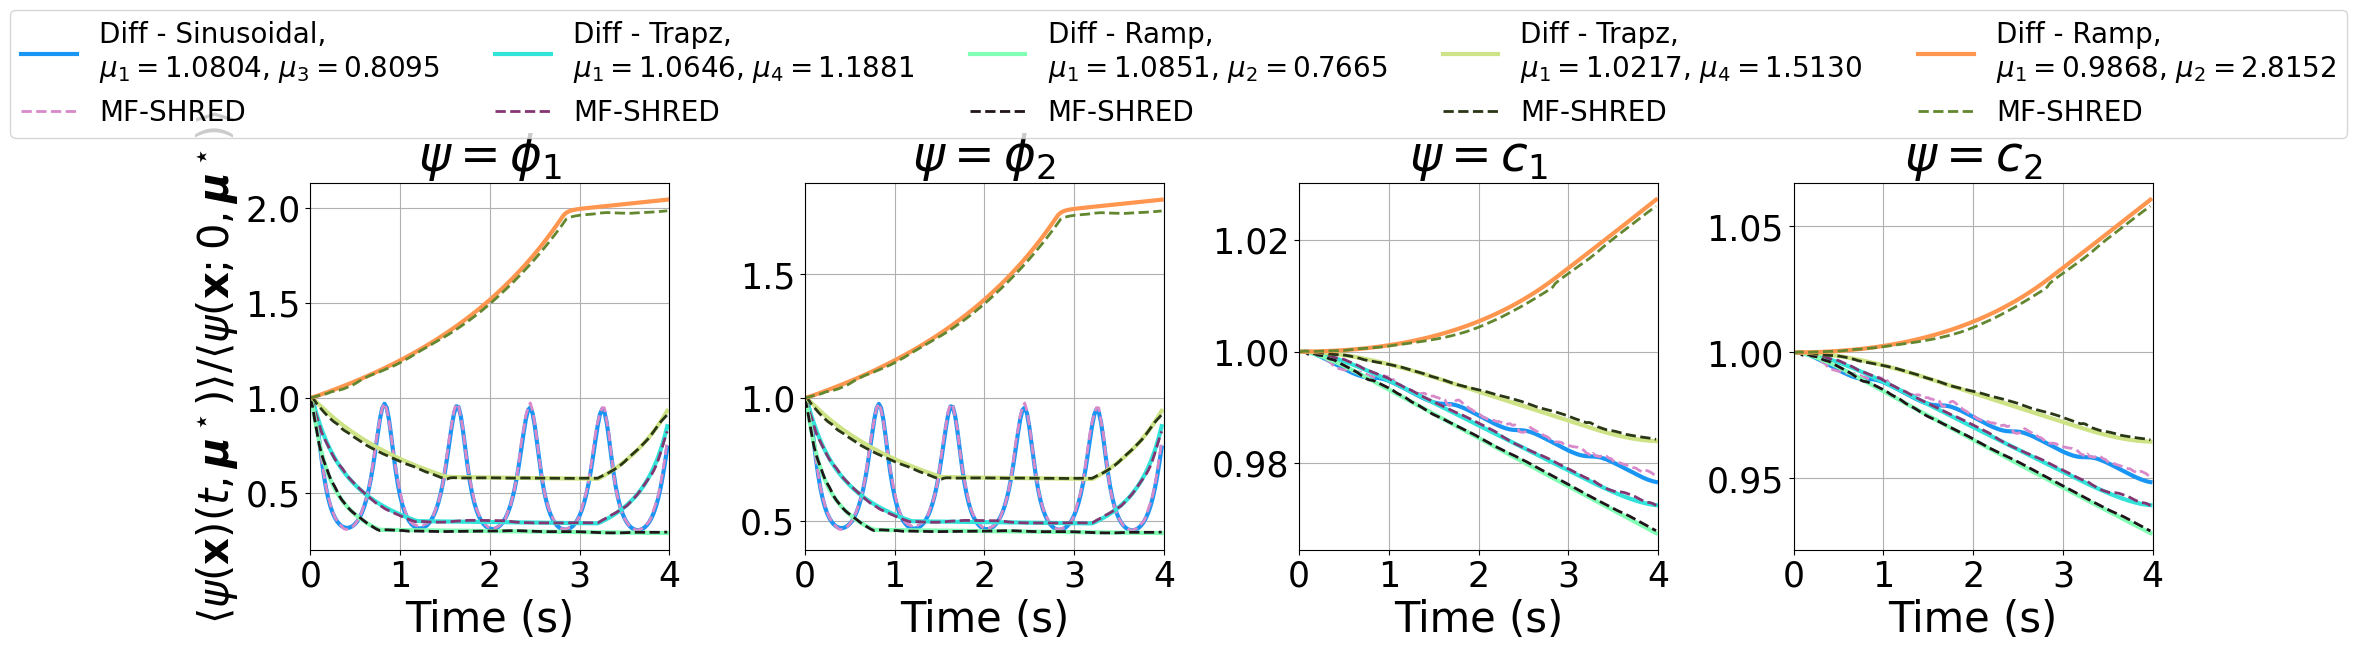

In [27]:
import matplotlib.lines as mlines

np.random.seed(42)
param_i_to_plot = np.sort(np.random.choice(test_shred_out.shape[0], 5))

fig, axs = plt.subplots(1, len(var_names), figsize=(5*len(var_names), 6))

colors_fom = cm.rainbow(np.linspace(0.2, 0.8, len(param_i_to_plot)))
colors_shred = cm.vanimo(np.linspace(0.1, 0.8, len(param_i_to_plot)))

for field_i, field in enumerate(var_names):

    _modes = modes[field][:, :Nmodes[field_i]]

    for idx, param_i in enumerate(param_i_to_plot):

        _test_snap  = snapshots[field][test_indices][param_i].T  # shape space x time
        axs[field_i].plot(np.arange(Nt)*dt, 
                          _test_snap.mean(axis=0) / _test_snap.mean(axis=0)[0],
                          '-', color=colors_fom[idx], linewidth=3, 
                          label=f'Diff - {test_list[param_i][1]},\n$'+test_list[param_i][3]+f'={test_list[param_i][2][0]:.4f}$, $'+test_list[param_i][4]+f'={test_list[param_i][2][1]:.4f}$')

        idx_out_shred = np.arange(sum(Nmodes[:field_i]), Nmodes[field_i] + sum(Nmodes[:field_i]), 1, dtype=int)
        _recon_snap = (_modes @ test_shred_out[param_i, :, idx_out_shred])
        axs[field_i].plot(np.arange(Nt)*dt, 
                          _recon_snap.mean(axis=0) / _recon_snap.mean(axis=0)[0],
                          '--', color=colors_shred[idx], linewidth=2, label='MF-SHRED')

    axs[field_i].set_title(r'$\psi='+f'{text_var_names[field_i]}$', fontsize=35)
    axs[field_i].set_xlabel('Time (s)', fontsize=30)
    axs[field_i].tick_params(axis='both', which='major', labelsize=25)
    axs[field_i].grid()
    axs[field_i].set_xlim(0, times[-1])
    axs[field_i].set_xticks(np.arange(0, times[-1]+1e-12, 1.0))

axs[0].set_ylabel(r'$\langle\psi(\mathbf{x})(t, \boldsymbol{\mu}^\star)\rangle / \langle\psi(\mathbf{x}; 0, \boldsymbol{\mu}^\star)\rangle$', fontsize=30)

_lin, _label = axs[0].get_legend_handles_labels()
fig.legend(_lin, _label, loc='upper center', fontsize=20, ncol=len(param_i_to_plot), bbox_to_anchor=(0.5, 1.1))

# # --- Create a single legend ---
# fom_line = mlines.Line2D([], [], color='black', linestyle='-', label='Diffusion')
# shred_line = mlines.Line2D([], [], color='black', linestyle='--', label='MF-SHRED')

# fig.legend(handles=[fom_line, shred_line],
#            loc=(0.35, 0.87), ncol=2, fontsize=30, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.9])  # leave space for legend

fig.savefig(path_results+'SHRED_spatial_average_comparison.pdf', format='pdf', dpi=250, bbox_inches='tight')